<a name="top" id="top"></a>

<div align="center">
    <h1>Graver Augmentation Multiseed Algorithm</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/pedromxavier">Pedro Maciel Xavier</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/murraybj">Benjamin J. L. Murray</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <i>Undergraduate Research Assistant</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/SECQUOIA/QuIP/blob/main/notebooks_py/3-GAMA_python.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

**Environment and execution notes**

For local execution from the repository root, run `uv sync --group qubo` before launching Jupyter so the Python scientific stack used below is available. If `Py4ti2int32` is installed, the notebook computes the Graver basis directly; otherwise it falls back to the bundled `graver.npy` file so the rest of the workflow still runs.

In Google Colab, the notebook reuses the bundled `graver.npy` file whenever `Py4ti2int32` is unavailable, which keeps the student-facing workflow focused on the GAMA steps rather than on an external 4ti2 installation.


## Graver Augmentation Multiseed Algorithm (Python)

### Introduction to GAMA

The Graver Augmentation Multiseed Algorithm (GAMA) was proposed by Alghassi, Dridi, and Tayur in the works listed in [Reference [1]](#gama-python-reference-1) and [Reference [2]](#gama-python-reference-2).
The three main ingredients of this algorithm, designed to solve integer programs with linear constraints and nonlinear objective, are:

- Computing the Graver basis (or a subset of it) of an integer program.
- Performing an augmentation.
- Given that only for certain objective functions, the Graver augmentation is guaranteed to find a globally optimal solution, the algorithm is initialized in several points.

This algorithm can be adapted to take advantage of Quantum Computers by leveraging them as black-box Ising/QUBO problem solvers.
In particular, obtaining several feasible solution points for the augmentation and computing the kernel of the constraint matrix can be posed as QUBO problems.
After obtaining these solutions, other routines implemented in classical computers are used to solve the optimization problems, making this a hybrid quantum-classical algorithm.

### Introduction to Graver basis computation

This notebook makes simple computations of Graver basis. Because of the complexity of these computations, we suggest that for more complicated problems you install the excellent **[4ti2](https://4ti2.github.io/)** software, an open-source implementation of several routines useful for the study of integer programming through algebraic geometry. It can be used as a stand-alone library and called from C++ or from Python. In Python, there are two ways of accessing it, either through **[Sage](https://www.sagemath.org/)** or by compiling 4ti2 directly and installing a **[Python wrapper](https://github.com/alfsan/Py4ti2)**.

A Graver basis is defined as

$$
\mathcal{G}(\mathbf{A}) = \bigcup_{j} \mathcal{H}_{j}(\mathbf{A})
$$

where $\mathcal{H}_{j}(\mathbf{A})$ are the minimal Hilbert basis of $\mathbf{A}$ in each orthant.

Equivalently we can define the Graver basis as the $\sqsubseteq$-minimal set of a lattice

$$
\mathcal{L}(\mathbf{A}) = \left\lbrace{}{\mathbf{x} : \mathbf{A} \mathbf{x} = 0, \mathbf{x} \in \mathbb{Z}^{n}}\right\rbrace{} \setminus \left\lbrace{}{0}\right\rbrace{} = \ker A \cap \mathbb{Z}^{n}
$$

where the partial ordering $\mathbf{x} \sqsubseteq \mathbf{y}$ holds whenever $x_i y_i \geq 0$ and $\left\vert x_i \right\vert \leq \left\vert y_i \right\vert$ for all $i$.

Here we won't interact with the Quantum Computer. However, we will obtain the Graver basis of a problem using package 4ti2. This notebook studies the behavior of the search algorithm in the case that we only have available a subset of the Graver basis.


In [1]:
try:
  import google.colab
  IN_COLAB = True
except Exception:
  IN_COLAB = False

try:
  if not IN_COLAB:
    from Py4ti2int32 import graver as py4ti2_graver
    HAS_PY4TI2 = True
  else:
    py4ti2_graver = None
    HAS_PY4TI2 = False
except ImportError:
  py4ti2_graver = None
  HAS_PY4TI2 = False


In [2]:
from pathlib import Path
from urllib.request import urlretrieve

from sympy import *
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable
import itertools
import random
import time


## Problem statement

The GAMA computation below uses Example 4 from the code, which corresponds to Case 2 in the original GAMA paper. The problem is derived from finance and deals with the maximization of expected returns on investments and the minimization of the variance.
$$
\min -\sum_{i=1}^n \mu_i x_i + \sqrt{\frac{1-\epsilon}{\epsilon}\sum_{i=1}^n \sigma_i^2 x_i^2} \\
\text{s.t. } A x = b, \; x \in \{-2,-1,0,1,2 \}^n
$$
This particular instance of convex INLP has $n=25$, $\epsilon=0.01$, $\mu_i = \text{Rand}[0,1]$, and $\sigma_i = \text{Rand}[0,\mu_i]$. The matrix $A$ is a matrix with 1's and 0's and the $b$ vector is half of the sum of the rows of $A$, in this case $b = (9,8,7,5,5)^\top$.

To make this Example 4 run reproducible, the notebook loads one fixed realization of the coefficient vectors from `notebooks_data/3-GAMA_example4_coefficients.csv`, reuses precomputed feasible starts from `notebooks_data/3-GAMA_example4_feasible_starts.csv`, and traverses a saved Graver-direction order from `notebooks_data/3-GAMA_example4_graver_order.csv`. The remaining GAMA method below uses this saved Example 4 instance: complete-basis greedy augmentation, a 10-direction partial-basis greedy augmentation, and several larger fractions of the basis.

The Graver basis of this matrix $A$ has 29789 elements, which on a standard laptop using 4ti2 takes about 5 seconds to compute. When `Py4ti2int32` is available, the notebook computes it directly; otherwise it reuses the bundled `graver.npy` file.


### Class examples

The original GAMA class notebook used `EXAMPLE = 1`, `EXAMPLE = 2`, `EXAMPLE = 3`, and `EXAMPLE = 4`. Examples 1-3 are retained here as class-reference problem definitions. The executable GAMA workflow below continues with the saved Example 4 portfolio instance.

#### Example 1: illustrative Graver augmentation

This example uses

$$
A = \begin{bmatrix} 1 & 1 & 1 & 1 \\ 1 & 5 & 10 & 25 \end{bmatrix},\quad
b = \begin{bmatrix} 21 \\ 156 \end{bmatrix},\quad
x^{(0)} = \begin{bmatrix} 1 & 15 & 3 & 2 \end{bmatrix}.
$$

The variable bounds are $0 \le x_i \le 15$. In the original class notebook, the objective is to minimize distance to 5.

#### Example 2: four-variable linear example

This example uses

$$
A = \begin{bmatrix} 1 & 1 & 1 & 1 \\ 1 & 2 & 3 & 4 \end{bmatrix},\quad
b = \begin{bmatrix} 10 \\ 21 \end{bmatrix},\quad
c = \begin{bmatrix} 0 & 1 & 0 & 2 \end{bmatrix},\quad
x^{(0)} = \begin{bmatrix} 1 & 8 & 0 & 1 \end{bmatrix}.
$$

The variable bounds are $0 \le x_i \le 21$.

#### Example 3: alternate four-variable linear example

This example uses

$$
A = \begin{bmatrix} 1 & 1 & 1 & 1 \\ 0 & 1 & 2 & 3 \end{bmatrix},\quad
b = \begin{bmatrix} 10 \\ 15 \end{bmatrix},\quad
c = \begin{bmatrix} 1 & 3 & 14 & 17 \end{bmatrix},\quad
x^{(0)} = \begin{bmatrix} 3 & 0 & 6 & 1 \end{bmatrix}.
$$

The variable bounds are $0 \le x_i \le 10$.

### Example 4: saved portfolio instance

Let

$$
A = \begin{bmatrix}
1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 0 & 1 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 1 & 0 & 1 & 0 & 1 & 0 \\
1 & 1 & 1 & 1 & 0 & 1 & 0 & 1 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 1 & 0 & 1 & 1 & 1 & 1 & 1 & 1 \\
0 & 1 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 0 & 0 & 1 & 0 & 0 & 1 & 1 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 1 & 1 & 0 & 1 & 1 & 1 & 1 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 1 & 1 & 1 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 1 & 0 \\
\end{bmatrix}
$$

This particular instance of convex INLP has $m = 5$, $n = 25$, $\varepsilon = 0.01$, $\mu_{i} = \textrm{rand}[0, 1]$, $\sigma_{i} = \textrm{rand}[0, \mu_{i}]$.
$A \in \mathbb{B}^{m \times n}$ and each $b_{j}$ is half the sum of the $j$-th row of $A$.
In this example, $\mathbf{b} = \left({9, 8, 7, 5, 5}\right)'$.

The remaining GAMA method below uses this saved Example 4 instance: complete-basis greedy augmentation, a 10-direction partial-basis greedy augmentation, and several larger fractions of the basis.


First we would write this problem as an unconstrained one by penalizing the linear constraints as quadratics in the objective.
Let's first define the problem parameters.


In [3]:
A = np.array([[1,1,1,1,1,1,1,1,1,1,0,1,0,1,0,1,0,1,1,1,0,1,0,1,0],
            [1,1,1,1,0,1,0,1,0,0,1,0,0,0,1,0,0,1,0,1,1,1,1,1,1],
            [0,1,0,0,0,1,0,1,0,1,1,0,1,1,0,1,1,0,0,1,0,0,1,1,1],
            [0,0,0,0,0,0,0,1,0,1,1,1,0,1,1,1,1,0,0,1,0,0,0,0,0],
            [0,1,1,1,1,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0]])
b = np.array([[9], [8], [7], [5], [5]])

# Objective is quadratic expression
x0 = np.array([1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, -2,
            1, 0, -1, 0, 1, -1, 1, -2, -2, 1, 1, 1])
x_lo = -2 * np.ones_like(x0)
x_up = 2 * np.ones_like(x0)

def resolve_example_data_path(filename: str) -> Path | None:
    """Return the path to a shared Notebook 3 data file when it exists."""
    candidates = [
        Path("notebooks_data") / filename,
        Path("..") / "notebooks_data" / filename,
        Path("/content/QuIP/notebooks_data") / filename,
        Path("/content/notebooks_data") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None

def load_shared_csv(filename: str, dtype=float) -> np.ndarray | None:
    """Load a shared Notebook 3 CSV asset when it is available."""
    data_path = resolve_example_data_path(filename)
    if data_path is None:
        return None
    return np.loadtxt(data_path, delimiter=",", dtype=dtype)

def load_shared_coefficients() -> tuple[np.ndarray, np.ndarray]:
    """Return the fixed `mu` and `sigma` vectors shared by both notebooks.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        The expected-return vector `mu` and the volatility vector `sigma`.
    """
    coeffs = load_shared_csv("3-GAMA_example4_coefficients.csv", dtype=float)
    if coeffs is None:
        rng = np.random.default_rng(1729)
        mu = rng.random(len(x0))
        sigma = rng.random(len(x0)) * mu
        print("Shared coefficient file not found; generating deterministic coefficients with seed 1729.")
        return mu, sigma

    coeffs = np.atleast_2d(coeffs)
    return coeffs[0], coeffs[1]

# Parameters of objective function
epsilon = 0.01
mu, sigma = load_shared_coefficients()

def load_precomputed_graver_basis() -> np.ndarray:
    """Load the bundled Graver basis from the repository or the Colab workspace."""
    candidates = [
        Path("notebooks_py") / "graver.npy",
        Path("graver.npy"),
        Path("/content/graver.npy"),
        Path("/content/QuIP/notebooks_py/graver.npy"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return np.array(np.load(candidate))

    download_path = Path("/content/graver.npy")
    download_path.parent.mkdir(parents=True, exist_ok=True)
    urlretrieve(
        "https://github.com/SECQUOIA/QuIP/raw/main/notebooks_py/graver.npy",
        download_path,
    )
    return np.array(np.load(download_path))

if HAS_PY4TI2:
    start = time.process_time()
    r = py4ti2_graver("mat", A.tolist())
    print(time.process_time() - start, 'seconds to compute Graver basis')
else:
    if not IN_COLAB:
        print('Py4ti2int32 is not available locally; loading the bundled graver.npy instead.')
    else:
        print('The Graver basis has 29789 elements in this case.')
    r = load_precomputed_graver_basis()


Py4ti2int32 is not available locally; loading the bundled graver.npy instead.


In [4]:
# Objective function definition
def f(x):
    """Evaluate the portfolio objective for a candidate point `x`."""
    return -np.dot(mu, x) + np.sqrt(((1 - epsilon) / epsilon) * np.dot(sigma**2, x**2))

# Constraints definition
def const(x):
    """Return True when `x` satisfies the linear constraints `A x = b`."""
    return np.array_equiv(np.dot(A, x), b.T) or np.array_equiv(np.dot(A, x), b)


In [5]:
# Define rules to choose augmentation element, either the best one (argmin) or the first one that is found
def argmin(iterable):
    """Return the index and value of the best augmentation candidate."""
    return min(enumerate(iterable), key=lambda x: x[1])

def greedy(iterable):
    """Return the first improving augmentation candidate, or the last one if none improve."""
    for i, val in enumerate(iterable):
        if val[1] != 0:
            return i, val
    else:
        return i, val


In [6]:
# Bisection rules for finding best step size
def bisection(g: np.ndarray, fun: Callable, x: np.ndarray, x_lo: np.ndarray = None, x_up: np.ndarray = None, laststep: np.ndarray = None) -> (float, int):
    """Compute the best integer step along a Graver direction within the box bounds."""
    if np.array_equal(g, laststep):
        return (fun(x), 0)
    if x_lo is None:
        x_lo = np.zeros_like(x)
    if x_up is None:
        x_up = np.ones_like(x) * max(x) * 2

    u = max(x_up) - min(x_lo)
    l = -(max(x_up) - min(x_lo))
    for i, gi in enumerate(g):
        if gi >= 1:
            if np.floor((x_up[i] - x[i]) / gi) < u:
                u = int(np.floor((x_up[i] - x[i]) / gi))
            if np.ceil((x_lo[i] - x[i]) / gi) > l:
                l = int(np.ceil((x_lo[i] - x[i]) / gi))
        elif gi <= -1:
            if np.ceil((x_up[i] - x[i]) / gi) > l:
                l = int(np.ceil((x_up[i] - x[i]) / gi))
            if np.floor((x_lo[i] - x[i]) / gi) < u:
                u = int(np.floor((x_lo[i] - x[i]) / gi))
    alpha = u

    while u - l > 1:
        if fun(x + l * g) < fun(x + u * g):
            alpha = l
        else:
            alpha = u
        p1 = int(np.floor((l + u) / 2) - 1)
        p2 = int(np.floor((l + u) / 2))
        p3 = int(np.floor((l + u) / 2) + 1)
        if fun(x + p1 * g) < fun(x + p2 * g):
            u = int(np.floor((l + u) / 2))
        elif fun(x + p3 * g) < fun(x + p2 * g):
            l = int(np.floor((l + u) / 2) + 1)
        else:
            alpha = p2
            break

    if fun(x + l * g) < fun(x + u * g) and fun(x + l * g) < fun(x + alpha * g):
        alpha = l
    elif fun(x + u * g) < fun(x + alpha * g):
        alpha = u

    return (fun(x + alpha * g), alpha)


In [7]:
# We can just have a single step move (works well with greedy approach)
def single_move(g: np.ndarray, fun: Callable, x: np.ndarray, x_lo: np.ndarray = None, x_up: np.ndarray = None, laststep: np.ndarray = None) -> (float, int):
    """Evaluate whether a single forward or backward step improves the objective."""
    if x_lo is None:
        x_lo = np.zeros_like(x)
    if x_up is None:
        x_up = np.ones_like(x) * max(x) * 2

    alpha = 0

    if (x + g <= x_up).all() and (x + g >= x_lo).all():
        if fun(x + g) < fun(x):
            alpha = 1
    elif (x - g <= x_up).all() and (x - g >= x_lo).all():
        if fun(x - g) < fun(x) and fun(x - g) < fun(x + g):
            alpha = -1

    return (fun(x + alpha * g), alpha)


In [8]:
def augmentation(grav = r, func = f, x = x0, x_lo = x_lo, x_up = x_up, OPTION: int = 1, VERBOSE: bool = True, itermax: int = 1000) -> (int, float, np.ndarray):
    """Apply a Graver augmentation rule until convergence.

    Parameters
    ----------
    grav : np.ndarray
        Candidate Graver directions, one row per direction.
    func : Callable
        Objective function evaluated after each trial step.
    x : np.ndarray
        Starting feasible point.
    x_lo, x_up : np.ndarray
        Componentwise lower and upper bounds enforced during step selection.
    OPTION : int
        `1` for best-improving bisection, `2` for first improving bisection, and `3` for first improving single moves.
    VERBOSE : bool
        When `True`, print the accepted step information at every iteration.
    itermax : int
        Maximum number of augmentation iterations.

    Returns
    -------
    tuple[int, float, np.ndarray]
        The number of iterations performed, the last objective value, and the final point.
    """
    # OPTION = 1 # Best augmentation, select using bisection rule
    # OPTION = 2 # Greedy augmentation, select using bisection rule
    # OPTION = 3 # Greedy augmentation, select using first found

    dist = 1
    gprev = None
    k = 1
    if VERBOSE:
        print("Initial point:", x)
        print("Objective function:", func(x))
    while dist != 0 and k < itermax:
        if OPTION == 1:
            g1, (obj, dist) = argmin(
                bisection(g=e, fun=func, x=x, laststep=gprev, x_lo=x_lo, x_up=x_up) for e in grav)
        elif OPTION == 2:
            g1, (obj, dist) = greedy(
                bisection(g=e, fun=func, x=x, laststep=gprev, x_lo=x_lo, x_up=x_up) for e in grav)
        elif OPTION == 3:
            g1, (obj, dist) = greedy(
                single_move(g=e, fun=func, x=x, x_lo=x_lo, x_up=x_up) for e in grav)
        else:
            print("Option not implemented")
            break
        x = x + grav[g1] * dist
        gprev = grav[g1]
        if VERBOSE:
            print("Iteration ", k)
            print(g1, (obj, dist))
            print("Augmentation direction:", gprev)
            print("Distanced moved:", dist)
            print("Step taken:", grav[g1] * dist)
            print("Objective function:", obj)
            print(func(x))
            print("Current point:", x)
            print("Are constraints satisfied?", const(x))
        else:
            if k % 50 == 0:
                print(k)
                print(obj)
        k += 1
    return (k, obj, x)


First, we will compare our augmentation strategies, either best or greedy, and for greedy, either computing the best step or a single move. In the order that was mentioned, the augmentation will take more iterations, but each one of the augmentation steps or iterations is going to be cheaper.

In [9]:
print('Best-augmentation: Choosing among the best step that each element of G can do (via bisection), the one that reduces the most the objective')
start = time.process_time()
iter,f_obj,xf = augmentation(func = f, OPTION=1,VERBOSE=False)
print(time.process_time() - start, 'seconds')
print(iter, 'iterations')
print('solution:',f_obj,xf)

print('Greedy-best-augmentation: Choosing among the best step that each element of G can do (via bisection), the first one encountered that reduces the objective')
start = time.process_time()
iter,f_obj,xf = augmentation(func = f, OPTION=2,VERBOSE=False)
print(time.process_time() - start, 'seconds')
print(iter, 'iterations')
print('solution:',f_obj,xf)

print('Greedy-augmentation: Choosing among the first element of G that with a single step reduces the objective')
start = time.process_time()
iter,f_obj,xf = augmentation(func = f, OPTION=3,VERBOSE=False)
print(time.process_time() - start, 'seconds')
print(iter, 'iterations')
print('solution:',f_obj,xf)

Best-augmentation: Choosing among the best step that each element of G can do (via bisection), the one that reduces the most the objective


9.604795205999999 seconds
8 iterations
solution: -2.880981111528471 [ 0  0  1  1  0  0  2 -1  0  1  1  1  0  0  1  2  0  0  0  0  1  0  0  2
  2]
Greedy-best-augmentation: Choosing among the best step that each element of G can do (via bisection), the first one encountered that reduces the objective


1.447022801000001 seconds
42 iterations
solution: -2.880981111528471 [ 0  0  1  1  0  0  2 -1  0  1  1  1  0  0  1  2  0  0  0  0  1  0  0  2
  2]
Greedy-augmentation: Choosing among the first element of G that with a single step reduces the objective


0.5269068909999994 seconds
42 iterations
solution: -2.880981111528471 [ 0  0  1  1  0  0  2 -1  0  1  1  1  0  0  1  2  0  0  0  0  1  0  0  2
  2]


Now we can highlight another feature of the algorithm, computing starting feasible solutions. For this case we formulate a QUBO and solve it via annealing.
In this particular case, we will not encode the integer variables and will only look for feasible solutions with $x \in \{0,1\}^n$.


In [10]:
# Let's install with dimod and neal
if IN_COLAB:
    !pip install dimod
    !pip install dwave-neal
import dimod
import neal

In [11]:
def load_precomputed_feasible_starts() -> np.ndarray | None:
    """Return the committed feasible starts when available."""
    data = load_shared_csv("3-GAMA_example4_feasible_starts.csv", dtype=int)
    if data is None:
        return None
    return np.atleast_2d(data).astype(int)


def get_default_feasible_starts(A, b, sampler, samples=20) -> np.ndarray:
    """Load the committed feasible starts or recompute them with simulated annealing."""
    feasible = load_precomputed_feasible_starts()
    if feasible is not None:
        print(f"Loaded {len(feasible)} precomputed feasible solutions from 3-GAMA_example4_feasible_starts.csv.")
        return feasible

    print("Shared feasible-start file not found; recomputing feasible solutions with simulated annealing.")
    return get_feasible(A, b, sampler=sampler, samples=samples)


def load_graver_order(size: int) -> np.ndarray:
    """Return a saved ordering of the Graver directions, or a deterministic fallback."""
    order = load_shared_csv("3-GAMA_example4_graver_order.csv", dtype=int)
    if order is not None:
        order = np.atleast_1d(order).astype(int)
        if order.shape[0] != size:
            raise ValueError(f"Expected {size} Graver indices, found {order.shape[0]}.")
        return order

    rng = np.random.default_rng(271828)
    print("Shared Graver-order file not found; generating a deterministic permutation with seed 271828.")
    return rng.permutation(size)


def get_feasible(A, b, sampler, samples=20):
    """Sample binary feasible starting points by minimizing the QUBO residual.

    Parameters
    ----------
    A, b : np.ndarray
        Constraint matrix and right-hand side.
    sampler : object
        Binary quadratic model sampler used for the QUBO.
    samples : int
        Number of reads requested from the sampler.

    Returns
    -------
    np.ndarray
        Binary feasible starting points with one row per sample and one column per variable.
    """
    Q = np.dot(A.T, A) + np.diag(np.dot(-2 * b.T, A)[0])
    offset = int(np.dot(b.T, b)[0, 0])
    bqm = dimod.BinaryQuadraticModel(Q, "BINARY", offset=offset)
    sampleset = sampler.sample(bqm, num_reads=samples)
    feas_sols = [np.fromiter(sample.values(), dtype=int) for sample, energy in sampleset.data(['sample', 'energy']) if energy == 0]
    return np.unique(np.array(feas_sols, dtype=int), axis=0)


### QUBO formulation for feasible starting points

We now formulate a QUBO to generate diverse feasible starting points for the augmentation stage. In this part of the notebook, we only search over binary points with $x \in \{0,1\}^n$ before passing those feasible candidates to the classical augmentation routine.

To do that, we minimize the squared residual of the linear constraints over binary points:

$$
\min_{x \in \{0,1\}^n} \|Ax - b\|_2^2 = \min_{x \in \{0,1\}^n} x^\top A^\top A x - 2 b^\top A x + b^\top b.
$$

The constant term $b^\top b$ does not affect the minimizers, so the notebook stores it as an offset and builds the binary quadratic model from `Q = A^\top A + \operatorname{diag}(-2 b^\top A)`. Any sample with energy `0` is therefore a feasible starting point for the augmentation stage.


We use simulated annealing here because the goal is not a single feasible point but a diverse set of feasible starts. A MIP solver would typically stop after one optimum, while annealing can return several distinct zero-energy states of the same QUBO in one run.


In [12]:
simAnnSampler = neal.SimulatedAnnealingSampler()


In [13]:
feas_sols = get_default_feasible_starts(A, b, sampler=simAnnSampler, samples = 20)
graver_order = load_graver_order(r.shape[0])
print(len(feas_sols), ' feasible solutions ready.')


Loaded 20 precomputed feasible solutions from 3-GAMA_example4_feasible_starts.csv.
20  feasible solutions ready.


By default the notebook loads the committed feasible starts from `notebooks_data/3-GAMA_example4_feasible_starts.csv`, so the experiment begins from the same saved 20 binary points on every run. If that file is unavailable, the notebook falls back to simulated annealing and regenerates the starts with the local Ocean stack. We now apply the augmentation procedure to each feasible point and record the final objective, the runtime, and the number of iterations it takes. Here we use the greedy single-move augmentation rule because of runtime.


In [14]:
init_obj = np.zeros((len(feas_sols),1))
iters_full = np.zeros((len(feas_sols),1))
final_obj_full = np.zeros((len(feas_sols),1))
times_full = np.zeros((len(feas_sols),1))
for i,sol in enumerate(feas_sols):
    if not const(sol):
        print("Infeasible")
        pass
    init_obj[i] = f(sol)
    start = time.process_time()
    iter, f_obj, xf = augmentation(grav = r, func = f, x = sol, OPTION=3,VERBOSE=False)
    times_full[i] = time.process_time() - start
    iters_full[i] = iter
    final_obj_full[i] = f_obj

We record the initial objective function, the one after doing the augmentation, and the number of augmentation steps.

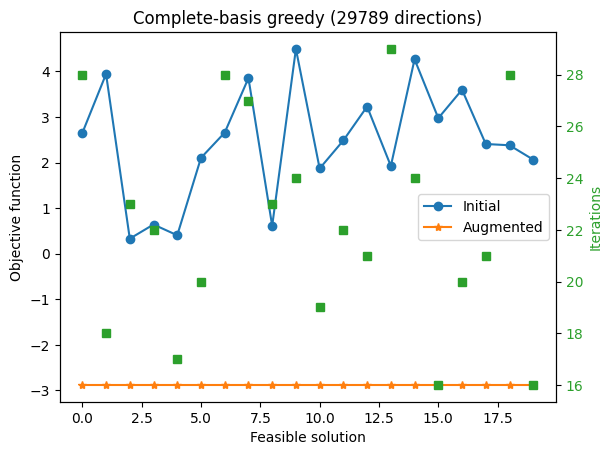

In [15]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax1.plot(init_obj, marker='o', ls='-', label='Initial')
ax1.plot(final_obj_full, marker='*', ls='-', label='Augmented')
ax1.set_ylabel('Objective function')
ax1.set_xlabel('Feasible solution')
ax1.set_title(f'Complete-basis greedy ({len(r)} directions)')

color = 'tab:green'
ax2.set_ylabel('Iterations', color=color)
ax2.plot(iters_full, color=color, marker='s', ls='')
ax2.tick_params(axis='y', labelcolor=color)
_ = ax1.legend()
plt.show()


With the complete Graver basis, every starting point improves substantially, but the final objective values can still differ. Here, complete basis refers to the direction set; the augmentation rule still uses greedy single-move selection for runtime on this nonseparable convex objective, so different feasible starts can terminate at different local optima.

Now let's try an extreme case, where we only have 10 of the elements of the Graver basis.


In [16]:
n_draws = 10  # for 10 shared Graver indices
index = graver_order[:n_draws]

iters_few = np.zeros((len(feas_sols),1))
final_obj_few = np.zeros((len(feas_sols),1))
times_few = np.zeros((len(feas_sols),1))
for i, sol in enumerate(feas_sols):
    if not const(sol):
        print("Infeasible")
        pass
    start = time.process_time()
    iter, f_obj, xf = augmentation(grav = r[index], x = sol, func = f, OPTION=3,VERBOSE=False)
    times_few[i] = time.process_time() - start
    iters_few[i] = iter
    final_obj_few[i] = f_obj


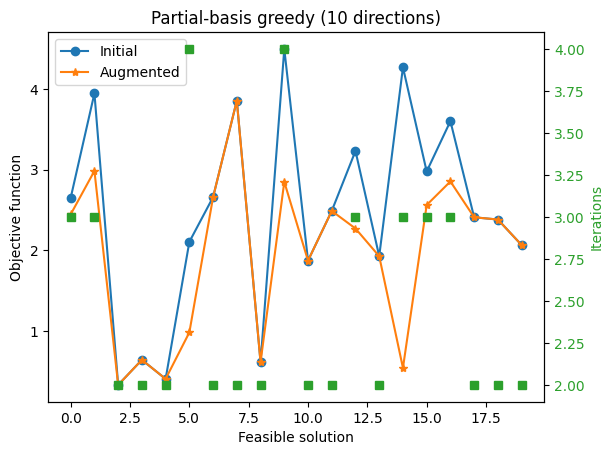

In [17]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax1.plot(init_obj, marker='o', ls='-', label='Initial')
ax1.plot(final_obj_few, marker='*', ls='-', label='Augmented')
ax1.set_ylabel('Objective function')
ax1.set_xlabel('Feasible solution')
ax1.set_title(f'Partial-basis greedy ({n_draws} directions)')

color = 'tab:green'
ax2.set_ylabel('Iterations', color=color)
ax2.plot(iters_few, color=color, marker='s', ls='')
ax2.tick_params(axis='y', labelcolor=color)
_ = ax1.legend()
plt.show()


With only 10 Graver directions, the augmentation runs quickly but often stalls after only a few improving moves.

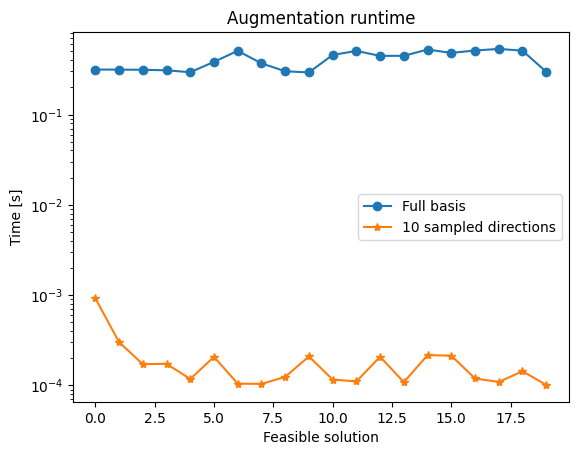

In [18]:
fig, ax1 = plt.subplots()

ax1.plot(times_full, marker='o', ls='-', label='Full basis')
ax1.plot(times_few, marker='*', ls='-', label=f'{n_draws} sampled directions')
ax1.set_ylabel('Time [s]')
ax1.set_xlabel('Feasible solution')
ax1.set_yscale('log')
ax1.set_title('Augmentation runtime')
_ = plt.legend()
plt.show()


This speed/quality tradeoff motivates the next experiment, which samples larger fractions of the Graver basis to look for a better middle ground.

In [19]:
N = 10 # Discretization of the fractions of Graver considered
iters = np.zeros((len(feas_sols),N-1))
final_obj = np.zeros((len(feas_sols),N-1))
times = np.zeros((len(feas_sols),N-1))
for j in range(1,N):

    n_draws = max(1, r.shape[0]//N*j)
    index = graver_order[:n_draws]

    for i, sol in enumerate(feas_sols):
        if not const(sol):
            print("Infeasible")
            pass
        start = time.process_time()
        iter, f_obj, xf = augmentation(grav = r[index], x = sol, func = f, OPTION=3,VERBOSE=False)
        times[i,j-1] = time.process_time() - start
        iters[i,j-1] = iter
        final_obj[i,j-1] = f_obj


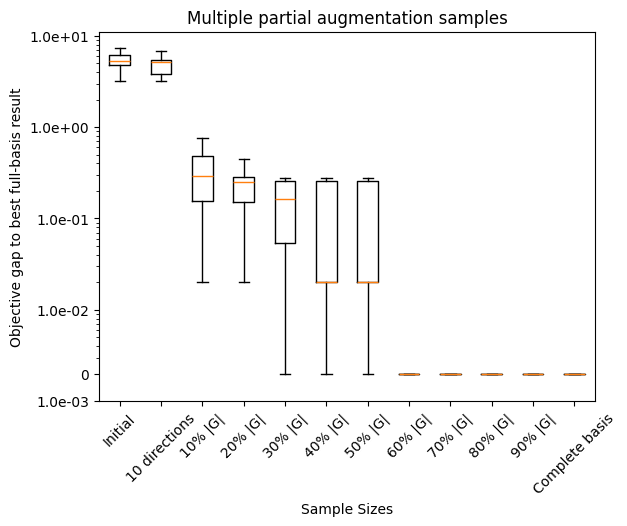

In [20]:
def lift_zero_objective_gaps(values: np.ndarray, global_minimum: float) -> tuple[np.ndarray, float]:
    """Return log-safe objective gaps and the floor used to display zero gaps."""
    gaps = np.maximum(values - global_minimum, 0.0)
    positive = gaps[gaps > 0]
    zero_floor = positive.min() / 10 if positive.size else np.finfo(float).eps
    adjusted = np.where(gaps > 0, gaps, zero_floor)
    return adjusted, zero_floor

def plot_objective_gap_boxplot(data: np.ndarray, labels: list[str], global_minimum: float) -> None:
    """Plot log-scaled objective gaps to the best full-basis result.

    Parameters
    ----------
    data : np.ndarray
        Objective values to compare, with one column per experiment.
    labels : list[str]
        Labels for the boxplot columns.
    global_minimum : float
        Best full-basis objective used as the baseline.

    Returns
    -------
    None
        Displays the boxplot in the notebook.
    """
    adjusted, zero_floor = lift_zero_objective_gaps(data, global_minimum)

    fig, ax = plt.subplots()
    ax.boxplot(adjusted)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Objective gap to best full-basis result')
    ax.set_xlabel('Sample Sizes')
    ax.set_yscale('log')
    ax.set_title('Multiple partial augmentation samples')

    tick_lo = int(np.floor(np.log10(adjusted.min())))
    tick_hi = int(np.ceil(np.log10(adjusted.max())))
    decade_ticks = 10.0 ** np.arange(tick_lo, tick_hi + 1)
    ticks = np.unique(np.concatenate(([zero_floor], decade_ticks)))
    ax.set_yticks(ticks)
    ax.set_yticklabels(['0' if np.isclose(t, zero_floor) else f'{t:.1e}' for t in ticks])

sample_labels = [f'{10 * i}% |G|' for i in range(1, N)]
sample_labels.insert(0, f'{10} directions')
sample_labels.append('Complete basis')
objective_labels = ['Initial', *sample_labels]

objective_gap_data = np.hstack((init_obj, final_obj_few, final_obj, final_obj_full))
plot_objective_gap_boxplot(objective_gap_data, objective_labels, float(np.min(final_obj_full)))
plt.xticks(rotation=45)
plt.show()


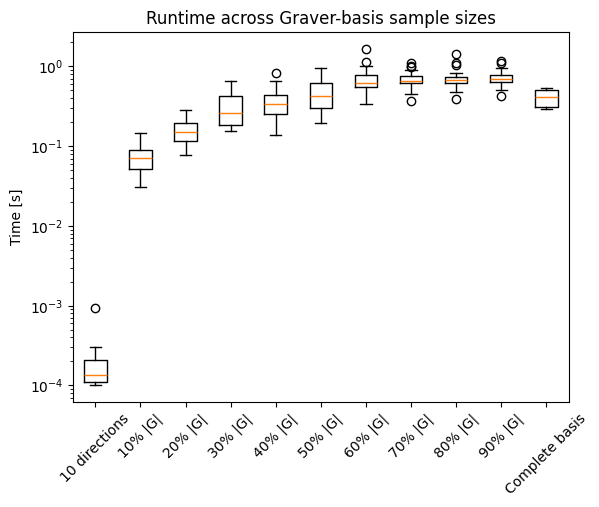

In [21]:
fig, ax1 = plt.subplots()

ax1.boxplot(np.hstack((times_few, times, times_full)))
runtime_labels = sample_labels
ax1.set_xticklabels(runtime_labels)
plt.ylabel('Time [s]')
ax1.set_yscale('log')
ax1.set_title('Runtime across Graver-basis sample sizes')
plt.xticks(rotation=45)
plt.show()


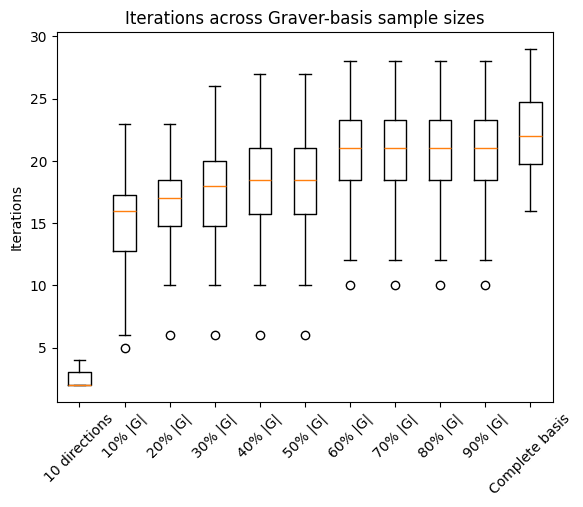

In [22]:
fig, ax1 = plt.subplots()

ax1.boxplot(np.hstack((iters_few, iters, iters_full)))
ax1.set_xticklabels(sample_labels)
plt.ylabel('Iterations')
ax1.set_title('Iterations across Graver-basis sample sizes')
plt.xticks(rotation=45)
plt.show()


### References

(gama-python-reference-1)=
- [1] M. Alghassi, S. Dridi, and M. Tayur, [arXiv:1902.04215](https://arxiv.org/abs/1902.04215)
(gama-python-reference-2)=
- [2] M. Alghassi, S. Dridi, and M. Tayur, [arXiv:1907.10930](https://arxiv.org/abs/1907.10930)
(gama-python-reference-3)=
- [3] [QuIPML22](https://github.com/bernalde/QuIPML22/)
